In [1]:
# Import necessary libraries
import torch
import torchvision
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

## Preprocessing

In [2]:
# Load MNIST dataset (train + test) from torchvision
transform = torchvision.transforms.ToTensor()

# Load training portion of MNIST (60,000 images)
train_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

# Load test portion of MNIST (10,000 images)
test_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# Combine data from both train and test sets
full_data = torch.utils.data.ConcatDataset([train_dataset, test_dataset])

# Extract all images and labels
X = []
y = []

for img, label in full_data:
    X.append(img.numpy())      # Convert tensor to numpy
    y.append(label)

X = np.array(X)  # Shape: (70000, 1, 28, 28)
y = np.array(y)  # Shape: (70000,)

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    train_size=0.6,
    stratify=y,           # Ensures class balance across splits
    random_state=42       # For reproducibility
)

# Second split: 50% val, 50% test of temp → each 20% of total
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,         # Split 40% → 20% and 20%
    stratify=y_temp,
    random_state=42
)

# Reshape: flatten 28x28 images to 784-dimensional vectors
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (42000, 784)
X_val_flat = X_val.reshape(X_val.shape[0], -1)        # (14000, 784)
X_test_flat = X_test.reshape(X_test.shape[0], -1)     # (14000, 784)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_flat, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDataset for each split
train_dataset_flat = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset_flat = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset_flat = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders with batch size 64 (common default)
batch_size = 64

train_loader = DataLoader(train_dataset_flat, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset_flat, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset_flat, batch_size=batch_size, shuffle=False)

# Verify shapes
print("Training data shape:", X_train_tensor.shape)   # Should be (42000, 784)
print("Validation data shape:", X_val_tensor.shape)   # (14000, 784)
print("Test data shape:", X_test_tensor.shape)        # (14000, 784)
print("Train loader batch count:", len(train_loader)) # ~657 batches (42000/64)

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.54MB/s]


Training data shape: torch.Size([42000, 784])
Validation data shape: torch.Size([14000, 784])
Test data shape: torch.Size([14000, 784])
Train loader batch count: 657


In [3]:
import torch.nn as nn
import torch.nn.functional as F

# Custom Feedforward Neural Network
class FeedforwardNN(nn.Module):
    def __init__(self, input_size=784, hidden1=256, hidden2=128, output_size=10):
        super(FeedforwardNN, self).__init__()
        
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_size)
        
        # Initialize weights (Xavier initialization)
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)
        
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)
        
        nn.init.xavier_uniform_(self.fc3.weight)
        nn.init.zeros_(self.fc3.bias)

    def forward(self, x):
        # Forward pass with ReLU activations
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # Output logits (no softmax here, handled by loss fn)
        return x


# Instantiate model
model = FeedforwardNN(input_size=784, hidden1=256, hidden2=128, output_size=10)

# Check architecture
print(model)

# Example: run one batch through the model to verify shapes
sample_batch, _ = next(iter(train_loader))
print("Input batch shape:", sample_batch.shape)  # [64, 784]
output = model(sample_batch)
print("Output shape:", output.shape)             # [64, 10]


FeedforwardNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)
Input batch shape: torch.Size([64, 784])
Output shape: torch.Size([64, 10])


In [13]:
import torch.optim as optim

# Device configuration (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move model to device
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

Using device: cuda


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Tracking lists
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

num_epochs = 30
patience = 3
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()
    running_loss, running_acc = [], []

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss.append(loss.item())
        _, predicted = outputs.max(1)
        acc = predicted.eq(targets).sum().item() / targets.size(0)
        running_acc.append(acc)

    train_loss = np.mean(running_loss)
    train_acc = np.mean(running_acc)

    model.eval()
    val_running_loss, val_running_acc = [], []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_running_loss.append(loss.item())
            _, predicted = outputs.max(1)
            acc = predicted.eq(targets).sum().item() / targets.size(0)
            val_running_acc.append(acc)

    val_loss = np.mean(val_running_loss)
    val_acc = np.mean(val_running_acc)

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Logging
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% "
          f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_model.pth")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break


Epoch [1/30] Train Loss: 0.0194, Train Acc: 99.70% | Val Loss: 0.0918, Val Acc: 97.16%
Epoch [2/30] Train Loss: 0.0188, Train Acc: 99.71% | Val Loss: 0.0901, Val Acc: 97.29%
Epoch [3/30] Train Loss: 0.0183, Train Acc: 99.73% | Val Loss: 0.0887, Val Acc: 97.33%
Epoch [4/30] Train Loss: 0.0179, Train Acc: 99.72% | Val Loss: 0.0893, Val Acc: 97.29%
Epoch [5/30] Train Loss: 0.0175, Train Acc: 99.75% | Val Loss: 0.0883, Val Acc: 97.31%
Epoch [6/30] Train Loss: 0.0172, Train Acc: 99.75% | Val Loss: 0.0878, Val Acc: 97.40%
Epoch [7/30] Train Loss: 0.0167, Train Acc: 99.76% | Val Loss: 0.0881, Val Acc: 97.34%
Epoch [8/30] Train Loss: 0.0163, Train Acc: 99.79% | Val Loss: 0.0893, Val Acc: 97.29%
Epoch [9/30] Train Loss: 0.0160, Train Acc: 99.78% | Val Loss: 0.0884, Val Acc: 97.32%
Early stopping triggered.


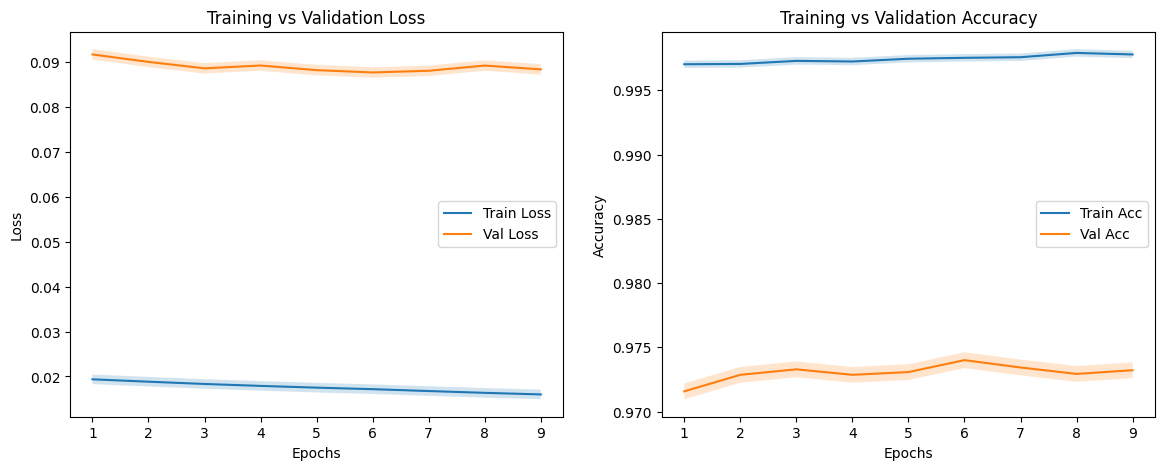

In [15]:
import matplotlib.pyplot as plt
import numpy as np

model.load_state_dict(best_model_wts)

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(14, 5))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.fill_between(epochs, 
                 np.array(train_losses)-np.std(train_losses),
                 np.array(train_losses)+np.std(train_losses),
                 alpha=0.2)
plt.fill_between(epochs, 
                 np.array(val_losses)-np.std(val_losses),
                 np.array(val_losses)+np.std(val_losses),
                 alpha=0.2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Acc")
plt.plot(epochs, val_accuracies, label="Val Acc")
plt.fill_between(epochs, 
                 np.array(train_accuracies)-np.std(train_accuracies),
                 np.array(train_accuracies)+np.std(train_accuracies),
                 alpha=0.2)
plt.fill_between(epochs, 
                 np.array(val_accuracies)-np.std(val_accuracies),
                 np.array(val_accuracies)+np.std(val_accuracies),
                 alpha=0.2)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()


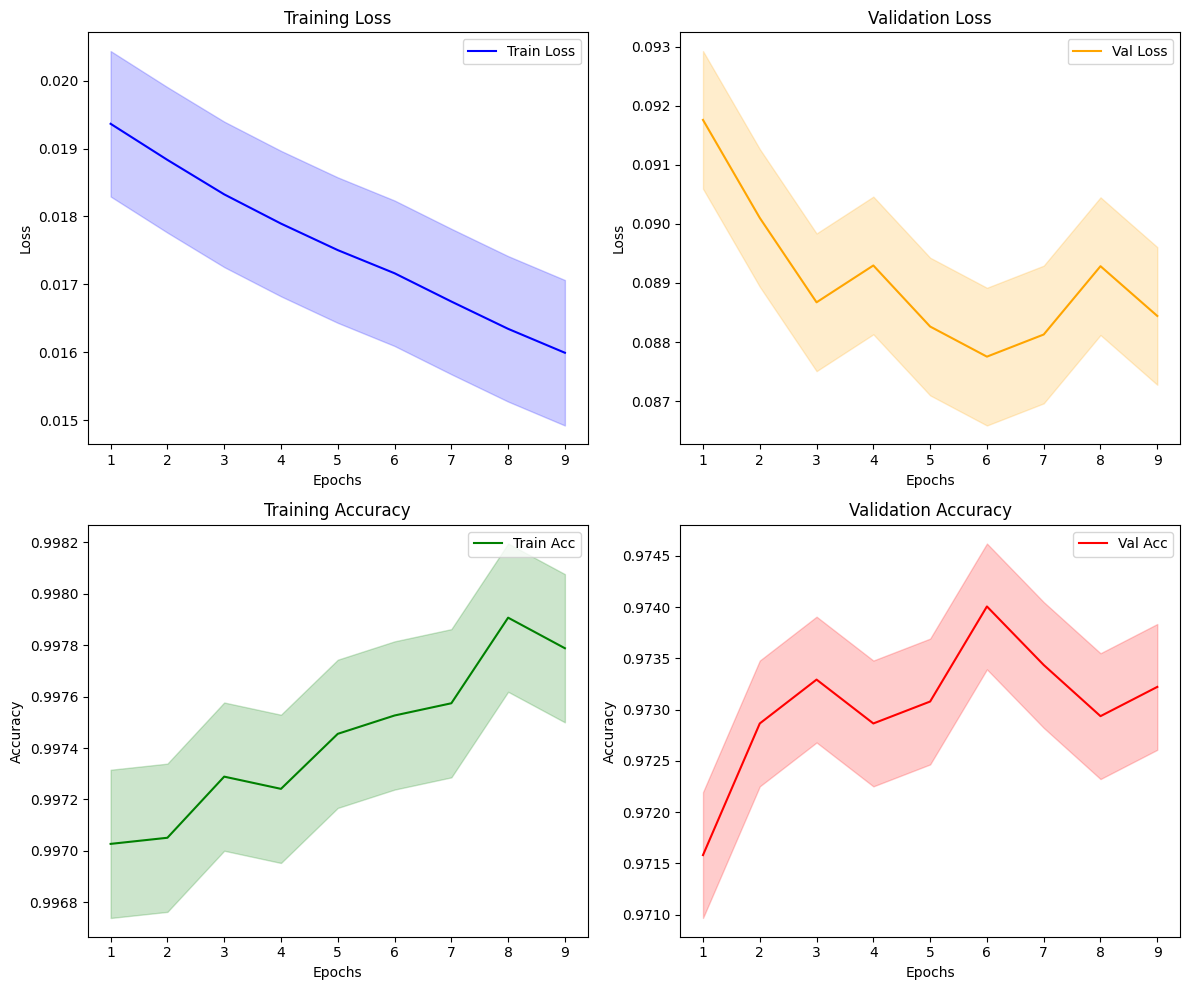

In [16]:
# ------------------
# Separate Plots
# ------------------
epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12, 10))

# Training Loss
plt.subplot(2, 2, 1)
plt.plot(epochs, train_losses, color="blue", label="Train Loss")
plt.fill_between(epochs,
                 np.array(train_losses)-np.std(train_losses),
                 np.array(train_losses)+np.std(train_losses),
                 alpha=0.2, color="blue")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

# Validation Loss
plt.subplot(2, 2, 2)
plt.plot(epochs, val_losses, color="orange", label="Val Loss")
plt.fill_between(epochs,
                 np.array(val_losses)-np.std(val_losses),
                 np.array(val_losses)+np.std(val_losses),
                 alpha=0.2, color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Loss")
plt.legend()

# Training Accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, train_accuracies, color="green", label="Train Acc")
plt.fill_between(epochs,
                 np.array(train_accuracies)-np.std(train_accuracies),
                 np.array(train_accuracies)+np.std(train_accuracies),
                 alpha=0.2, color="green")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()

# Validation Accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, val_accuracies, color="red", label="Val Acc")
plt.fill_between(epochs,
                 np.array(val_accuracies)-np.std(val_accuracies),
                 np.array(val_accuracies)+np.std(val_accuracies),
                 alpha=0.2, color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()
